In [1]:
import os
import torch
from PIL import Image
import my_models_mae
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [2]:
from typing import Any, Literal

import numpy as np
import numpy.typing as npt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import ElasticNet, LogisticRegression
from sklearn.metrics import f1_score  # pyright: ignore [reportUnknownVariableType]
from sklearn.metrics import (
    mean_squared_error,  # pyright: ignore [reportUnknownVariableType]
)
from sklearn.metrics import (
    precision_recall_curve,  # pyright: ignore [reportUnknownVariableType]
)
from sklearn.metrics import (
    precision_score,  # pyright: ignore [reportUnknownVariableType]
)
from sklearn.metrics import recall_score  # pyright: ignore [reportUnknownVariableType]
from sklearn.metrics import roc_auc_score  # pyright: ignore [reportUnknownVariableType]
from sklearn.metrics import (
    root_mean_squared_error,  # pyright: ignore [reportUnknownVariableType]
)
from sklearn.metrics import (
    accuracy_score,
    auc,
    brier_score_loss,
    confusion_matrix,
    mean_absolute_error,
    r2_score,
)
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.exceptions import ConvergenceWarning
import h5py

import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)


def get_metrics(
    labels: npt.NDArray[Any], probas: npt.NDArray[Any], preds: npt.NDArray[Any]
):
    assert (
        len(labels) == len(probas) == len(preds)
    ), f"{len(labels)}, {len(probas)}, {len(preds)}"
    metrics: dict[str, float | list[int] | list[float]] = {}
    metrics["support"] = len(labels)
    metrics["support_per_class"] = np.unique(labels, return_counts=True)[
        1
    ].tolist()  # pyright: ignore
    metrics["accuracy"] = float(accuracy_score(labels, preds))
    metrics["precision"] = float(
        precision_score(labels, preds, average="macro")  # pyright: ignore
    )
    metrics["precision_per_class"] = precision_score(
        labels, preds, average=None
    ).tolist()  # pyright: ignore
    metrics["recall"] = float(
        recall_score(labels, preds, average="macro")  # pyright: ignore
    )
    metrics["recall_per_class"] = recall_score(
        labels, preds, average=None
    ).tolist()  # pyright: ignore
    metrics["f1"] = float(f1_score(labels, preds, average="macro"))  # pyright: ignore
    metrics["f1_per_class"] = f1_score(
        labels, preds, average=None
    ).tolist()  # pyright: ignore
    if np.unique(labels)[-1] == 1:  # binary classification
        metrics["precision_binary_pos"] = float(
            precision_score(labels, preds)  # pyright: ignore
        )
        metrics["recall_binary_pos"] = float(
            recall_score(labels, preds)  # pyright: ignore
        )
        metrics["f1_binary_pos"] = float(f1_score(labels, preds))  # pyright: ignore
        # works only in binary case
        precision, recall, _ = precision_recall_curve(  # pyright: ignore
            labels, probas[:, 1]
        )
        metrics["pr_auc_binary"] = float(auc(recall, precision))  # pyright: ignore
        metrics["roc_auc"] = float(
            roc_auc_score(labels, probas[:, 1], average="macro")
        )  # pyright: ignore
    else:
        metrics["roc_auc"] = float(
            roc_auc_score(labels, probas, average="macro", multi_class="ovo")
        )  # pyright: ignore
    cm = confusion_matrix(labels, preds)  # pyright: ignore
    metrics["confusion_matrix"] = cm.tolist()  # pyright: ignore
    fp = cm.sum(axis=0) - np.diag(cm)  # pyright: ignore
    fn = cm.sum(axis=1) - np.diag(cm)  # pyright: ignore
    tp = np.diag(cm)  # pyright: ignore
    tn = cm.sum() - (fp + fn + tp)
    metrics["fp"] = fp.tolist()
    metrics["fn"] = fn.tolist()
    metrics["tp"] = tp.tolist()
    metrics["tn"] = tn.tolist()
    metrics["brier_inv"] = 1 - float(
        brier_score_loss(labels, probas, scale_by_half=True)  # pyright: ignore
    )
    brier_per_class: list[float] = []
    for label in np.unique(labels):
        mask = labels == label
        brier_per_class.append(
            1
            - float(
                brier_score_loss(  # pyright: ignore
                    np.ones_like(labels[mask]),
                    probas[mask, label],
                    scale_by_half=True,  # pyright: ignore
                )
            )
        )
    metrics["brier_inv_per_class"] = brier_per_class
    return metrics


def evaluate_by_classifier_probe(
    clf: LogisticRegression | RandomForestClassifier,
    embeddings: Any,
    labels: Any,
    train_idcs: Any | None = None,
    test_idcs: Any | None = None,
):
    if train_idcs is None or test_idcs is None:
        # should be fixed in numpy 1.25
        train_idcs = np.arange(  # pyright: ignore [reportUnknownMemberType]
            len(embeddings)
        )
        test_idcs = np.arange(  # pyright: ignore [reportUnknownMemberType]
            len(embeddings)
        )
    clf = clf.fit(embeddings[train_idcs], labels[train_idcs])  # pyright: ignore
    clf_probas: npt.NDArray[np.float32] = clf.predict_proba(  # pyright: ignore
        embeddings[test_idcs]
    )
    clf_preds: npt.NDArray[np.float32] = clf.predict(  # pyright: ignore
        embeddings[test_idcs]
    )
    return clf, clf_probas, clf_preds


def summarize(metrics: list[dict[str, float | list[int | float]]]):
    summary_dict: dict[str, float | list[int | float | list[int] | list[float]]] = {}
    for key in metrics[0].keys():
        d = np.array([m[key] for m in metrics])
        summary_dict[key] = d.tolist()
        summary_dict[key + "_mean"] = d.mean(axis=0).tolist()
        summary_dict[key + "_std"] = d.std(axis=0).tolist()
        if key == "confusion_matrix":
            summary_dict[key + "_sum"] = np.sum(
                [m[key] for m in metrics], axis=0
            ).tolist()
    return summary_dict


def plot_confusion_matrix(
    confusion_matrix: npt.NDArray[Any],
    display_labels: list[str],
    im_kw: dict[str, Any] = {},
    vmax: int | None = 300,
    title: str = "Confusion matrix",
    show: bool = False,
    save_path: str | None = None,
    plt_style: Literal["dark_background", "default"] = "default",
):
    plt.style.use(plt_style)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix, display_labels=display_labels
    )
    disp.plot(im_kw=im_kw)
    if vmax is not None:
        disp.ax_.get_images()[0].set_clim(0, vmax)
    plt.title(title)  # type: ignore
    plt.tight_layout()
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)  # type: ignore
    if show:
        plt.show()  # type: ignore
    else:
        plt.close()


def plot_images_grid(
    images: npt.NDArray[Any],
    title: str = "Images grid",
):
    n_cols = 6
    n_rows = np.ceil(len(images) / n_cols).astype(int)
    figsize = (n_cols * 3, n_rows * 3)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes_flat = axes.flatten()
    for i in range(n_rows):
        for j in range(n_cols):
            idx = i * n_cols + j
            if idx < len(images):
                axes_flat[idx].imshow(
                    images[idx], cmap="gray", vmin=-0.7378069, vmax=2.8465295
                )
            axes_flat[idx].axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def load_labels_from_h5py():
    p = "/g/kreshuk/hellgoth/projects/ML4ExM_project/ML4ExM/experiments/spheres_small_conext_contrastive/4uqsmnsh/predictions/best_otherVols/preds_best.hdf5"
    with h5py.File(p, "r") as f:
        labels = f["slice_labels_slice_specific"][:]
        dataset_idxs = f["dataset_idx_per_img"][:]
    return labels, dataset_idxs


def load_patch_labels_from_h5py():
    p = "/g/kreshuk/hellgoth/projects/ML4ExM_project/ML4ExM/experiments/spheres_small_conext_contrastive/4uqsmnsh/predictions/best_otherVols/preds_best.hdf5"
    with h5py.File(p, "r") as f:
        patch_labels = f["patch_labels"][:]
        dataset_idxs = f["dataset_idxs_per_patch"][:]
    return patch_labels, dataset_idxs

In [7]:
nucl_type_display_labels = ("dim nucl", "no nucl", "bright nucl")
labels, dataset_idxs = load_labels_from_h5py()
labels.shape, dataset_idxs.shape

((900,), (900,))

In [8]:
patch_labels, dataset_idxs_per_patch = load_patch_labels_from_h5py()
patch_labels.shape, dataset_idxs_per_patch.shape, patch_labels.min(), patch_labels.max()

((176400,), (176400,), 0, 3)

In [172]:
transform_train = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=0.17597473, std=0.23851053),
    ]
)

# CHANGED loader
def pil_loader_grey(path: str) -> Image:
    return Image.open(path)

dataset_val = datasets.ImageFolder(
    os.path.join("/scratch/hellgoth/data/spheres_small_2d_png/", "val"),
    loader=pil_loader_grey,
    transform=transform_train,
)
sample = dataset_val[0][0]
sample.shape, sample.min(), sample.max(), len(dataset_val)

(torch.Size([1, 224, 224]), tensor(-0.7378), tensor(1.5641), 900)

In [161]:
all_imgs = np.array([
    dataset_val[i][0][0].numpy().squeeze() for i in range(len(dataset_val))
])
all_imgs.shape

(900, 224, 224)

In [83]:
all_imgs.min(), all_imgs.max(), all_imgs.mean(), all_imgs.std()

(-0.7378069, 2.8465295, 0.015571069, 1.0074832)

In [84]:
# normal MAE, single channel, no norm pix loss

In [173]:
p = "/g/kreshuk/hellgoth/projects/ML4ExM_project/mae/spheres_maester6/checkpoint-799.pth"
ckpt = torch.load(p, map_location="cpu")
model = my_models_mae.__dict__["mae_vit_base_patch16"](
        norm_pix_loss=False,
        in_chans=1,
        loss_on_all_patches=False,
        pos_encode_w=1.0,
    )
model.load_state_dict(ckpt["model"])

<All keys matched successfully>

In [174]:
embeddings = np.zeros((len(dataset_val), 196, 768))
cls_embeddings = np.zeros((len(dataset_val), 768))
for i, sample in enumerate(tqdm(dataset_val)):  # sample is (image, label)
    latent, mask, ids_restore = model.forward_encoder(sample[0][None], 0.0)
    embeddings[i] = latent[0, 1:].detach().cpu().numpy()  # rmv cls token
    cls_embeddings[i] = latent[0, 0].detach().cpu().numpy()
embeddings.shape, cls_embeddings.shape

100%|██████████| 900/900 [00:56<00:00, 15.88it/s]


((900, 196, 768), (900, 768))

In [177]:
embeds.shape, patch_labels.shape

((176400, 768), (176400,))

[0.41436918362007746, 0.39904257767548906, 0.10311652423110383, 0.08501851644035462]


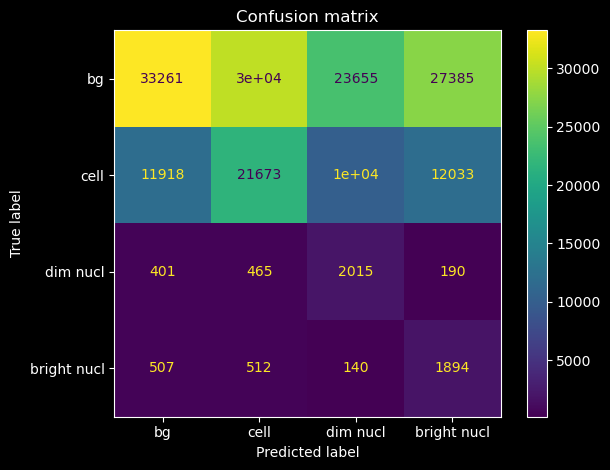

In [185]:
# patch level accum
embeds = embeddings.reshape(-1, embeddings.shape[-1])
preds = np.zeros((900*196,))
probas = np.zeros((900*196, 4))
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, patch_labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=patch_labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    probas[test_idcs] = clf_probas
    preds[test_idcs] = clf_preds
metrics = get_metrics(
    labels=patch_labels, probas=probas, preds=preds
)
print(metrics["f1_per_class"])
cm = confusion_matrix(patch_labels, preds)
plot_confusion_matrix(
    confusion_matrix=cm,
    display_labels=("bg", "cell", "dim nucl", "bright nucl"),
    # vmax=900*196*0.75,
    vmax=None,
    plt_style="dark_background",
    show=True,
)

In [87]:
# cls tokens
embeds = cls_embeddings
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[0.9611163954891294, 0.9525541056664374, 0.9666606048359938] [0.0185756827138976, 0.023536185906572655, 0.020261864884985836]


In [88]:
# cls tokens: accumulate over kfolds
embeds = cls_embeddings
preds = np.zeros((900,))
probas = np.zeros((900, 3))
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    probas[test_idcs] = clf_probas
    preds[test_idcs] = clf_preds
metrics = get_metrics(
    labels=labels, probas=probas, preds=preds
)
metrics["f1_per_class"]

[0.961082910321489, 0.9525368248772504, 0.9665551839464883]

In [89]:
cm = confusion_matrix(labels, preds)
cm

array([[284,  13,   3],
       [  3, 291,   6],
       [  4,   7, 289]])

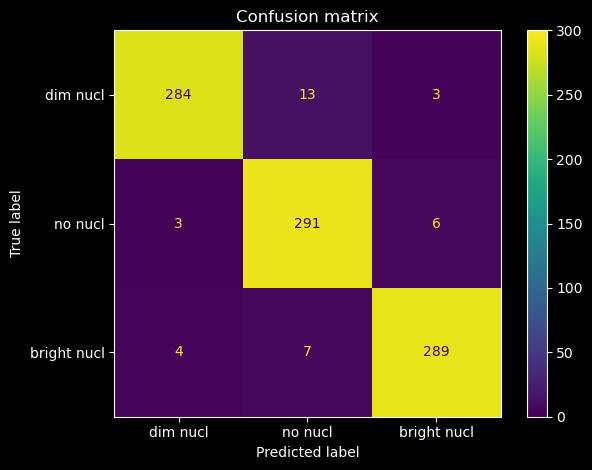

In [90]:
plot_confusion_matrix(
    confusion_matrix=cm,
    display_labels=nucl_type_display_labels,
    plt_style="dark_background",
    show=True,
)

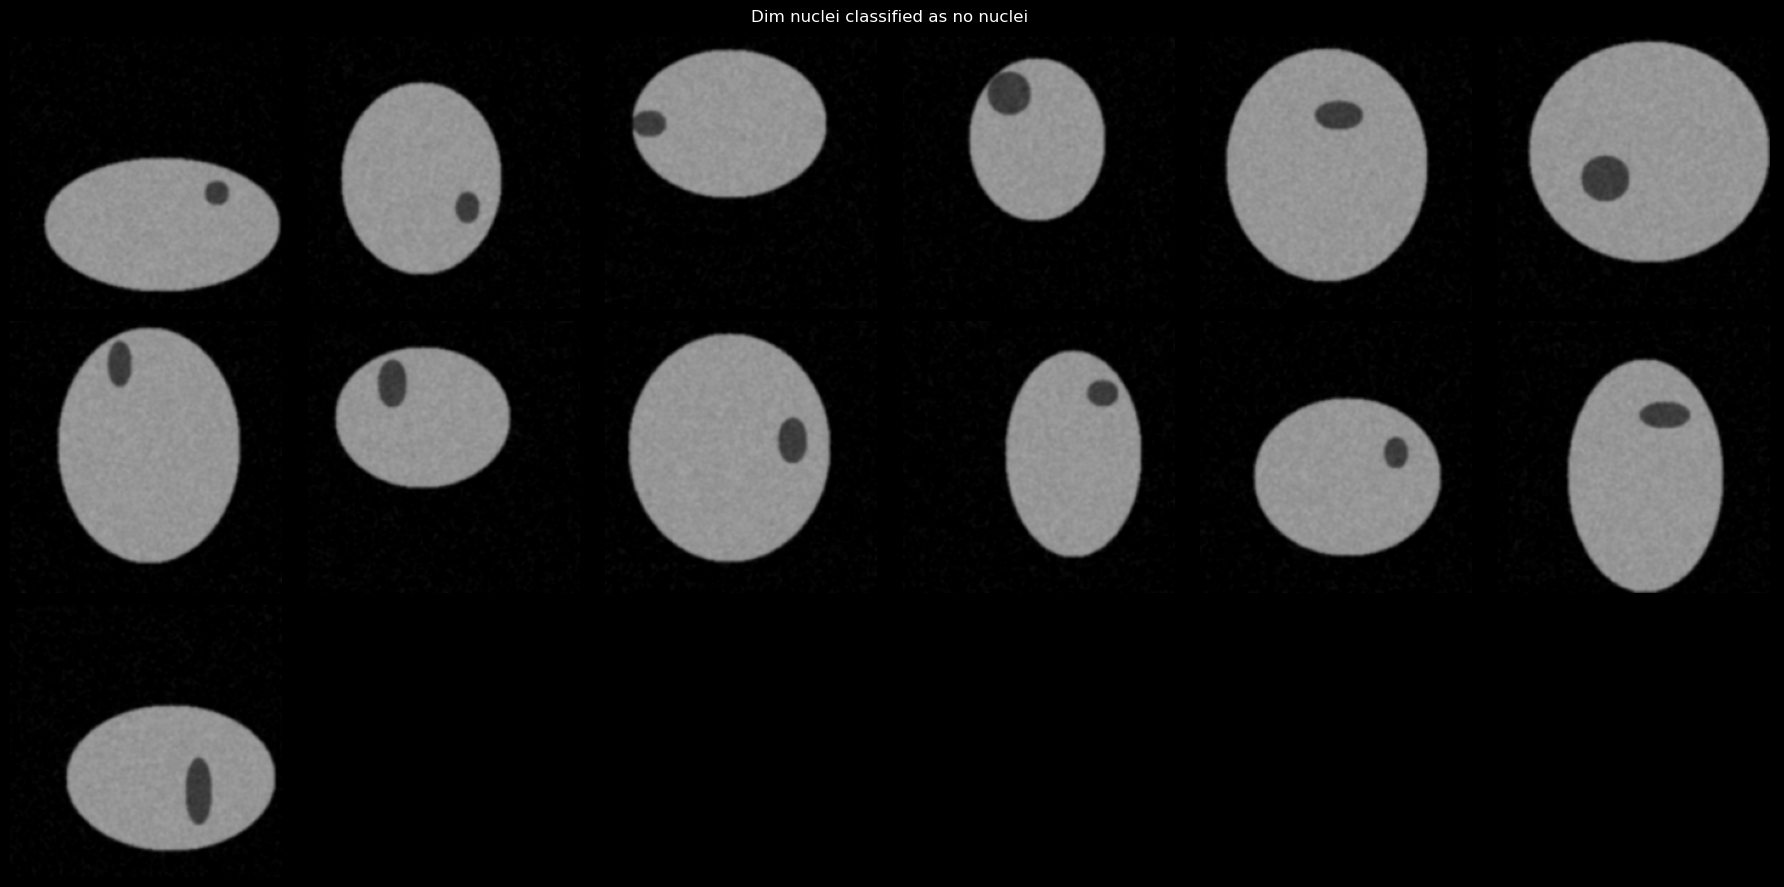

In [91]:
# dim but considered as no nucl
idcs = np.where((labels == 0) & (preds == 1))[0]
plot_images_grid(
    images=np.array([dataset_val[i][0][0].numpy().squeeze() for i in idcs]),
    title="Dim nuclei classified as no nuclei",
)

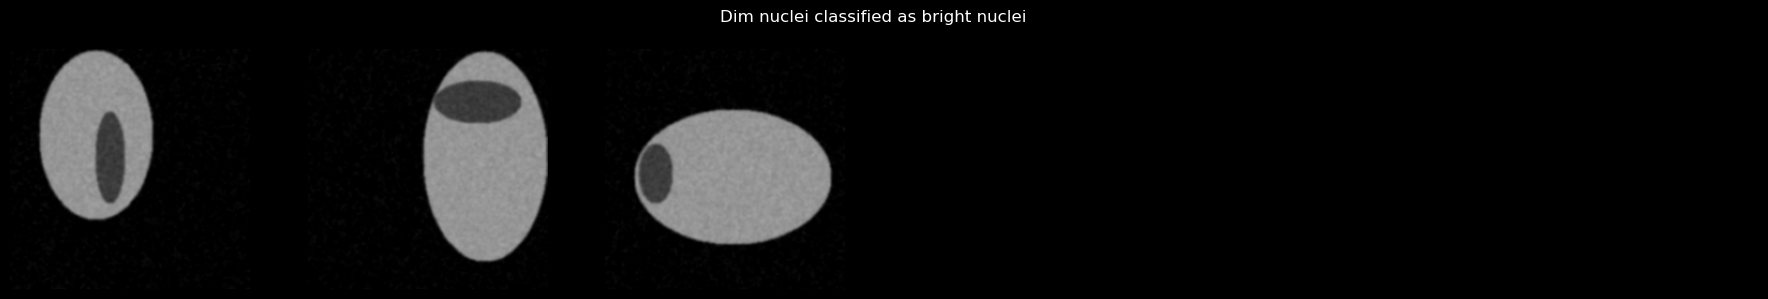

In [92]:
idcs = np.where((labels == 0) & (preds == 2))[0]
plot_images_grid(
    images=np.array([dataset_val[i][0][0].numpy().squeeze() for i in idcs]),
    title="Dim nuclei classified as bright nuclei",
)

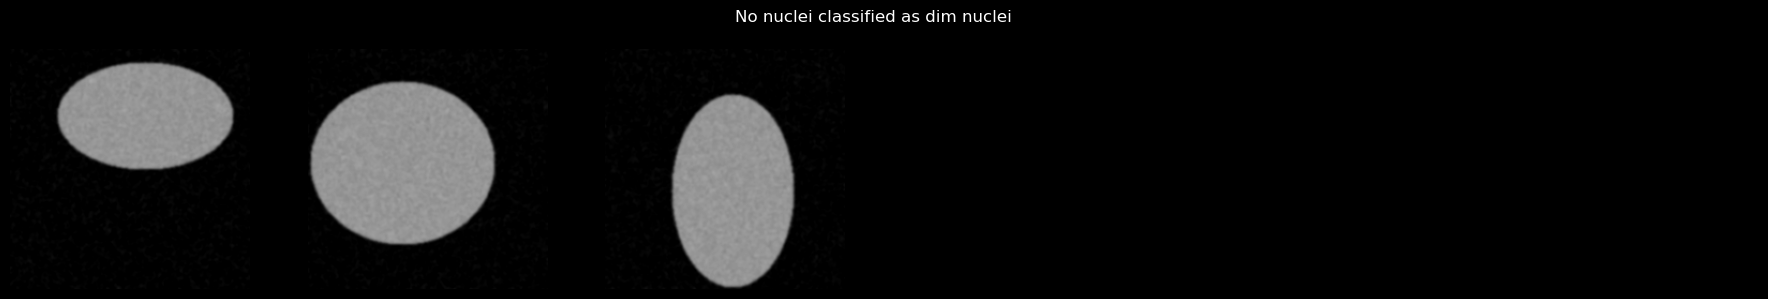

In [93]:
idcs = np.where((labels == 1) & (preds == 0))[0]
plot_images_grid(
    images=np.array([dataset_val[i][0][0].numpy().squeeze() for i in idcs]),
    title="No nuclei classified as dim nuclei",
)

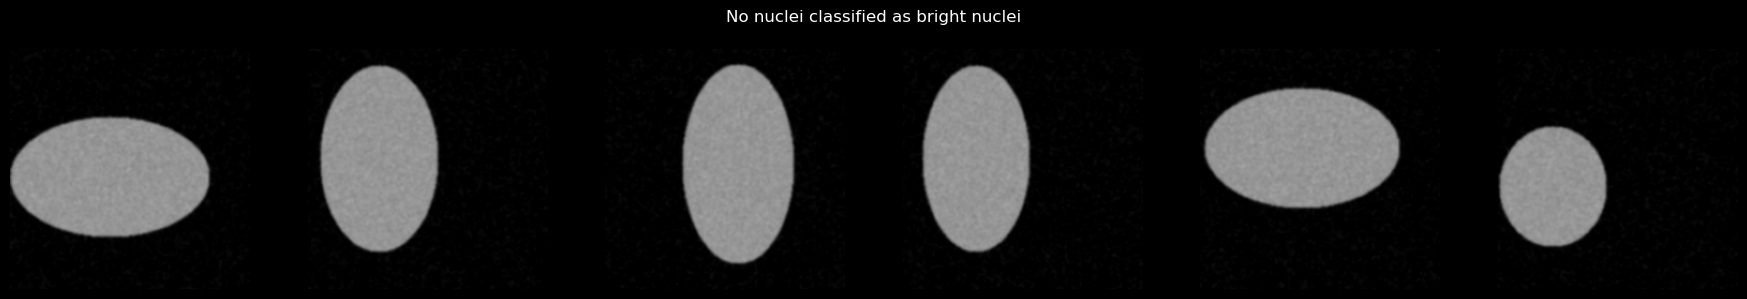

In [94]:
idcs = np.where((labels == 1) & (preds == 2))[0]
plot_images_grid(
    images=np.array([dataset_val[i][0][0].numpy().squeeze() for i in idcs]),
    title="No nuclei classified as bright nuclei",
)

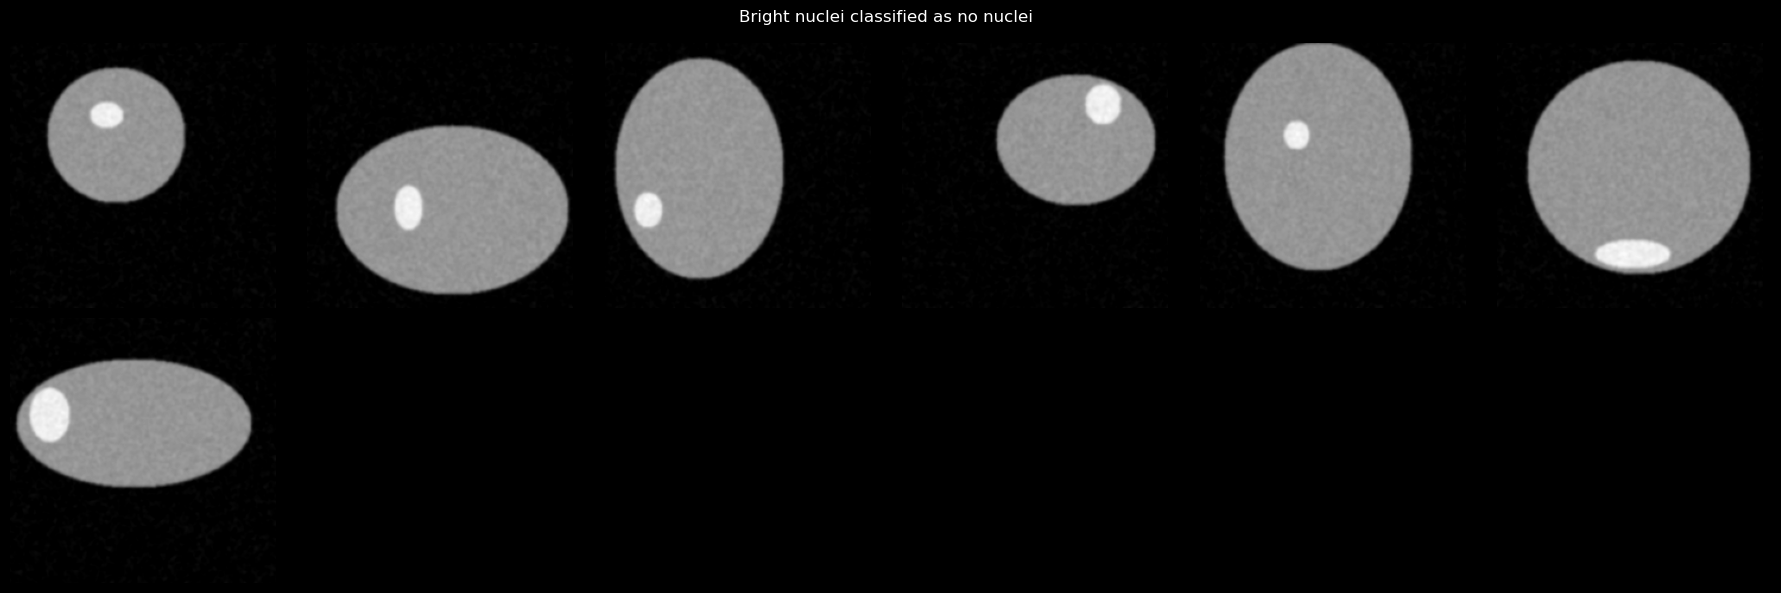

In [95]:
idcs = np.where((labels == 2) & (preds == 1))[0]
plot_images_grid(
    images=np.array([dataset_val[i][0][0].numpy().squeeze() for i in idcs]),
    title="Bright nuclei classified as no nuclei",
)

In [96]:
embeddings.mean(axis=1).shape

(900, 768)

In [97]:
# mean of patch embed
embeds = embeddings.mean(axis=1)
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[0.9966499162479062, 0.9917735615926125, 0.9949579547569497] [0.0023688669386484106, 0.00614832312571691, 0.004123737460945132]


In [98]:
# max of patch embed
embeds = embeddings.max(axis=1)
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[1.0, 1.0, 1.0] [0.0, 0.0, 0.0]


In [99]:
# normal MAE, single channel, no norm pix loss, loss on all patches

In [186]:
p = "/g/kreshuk/hellgoth/projects/ML4ExM_project/mae/spheres_maester7/checkpoint-799.pth"
ckpt = torch.load(p, map_location="cpu")
model = my_models_mae.__dict__["mae_vit_base_patch16"](
        norm_pix_loss=False,
        in_chans=1,
        loss_on_all_patches=True,
        pos_encode_w=1.0,
    )
model.load_state_dict(ckpt["model"])

<All keys matched successfully>

In [187]:
embeddings = np.zeros((len(dataset_val), 196, 768))
cls_embeddings = np.zeros((len(dataset_val), 768))
for i, sample in enumerate(tqdm(dataset_val)):  # sample is (image, label)
    latent, mask, ids_restore = model.forward_encoder(sample[0][None], 0.0)
    embeddings[i] = latent[0, 1:].detach().cpu().numpy()  # rmv cls token
    cls_embeddings[i] = latent[0, 0].detach().cpu().numpy()
embeddings.shape, cls_embeddings.shape

100%|██████████| 900/900 [00:57<00:00, 15.63it/s]


((900, 196, 768), (900, 768))

[0.44353892845483234, 0.39846613339363274, 0.11838948576196934, 0.109394299564194]


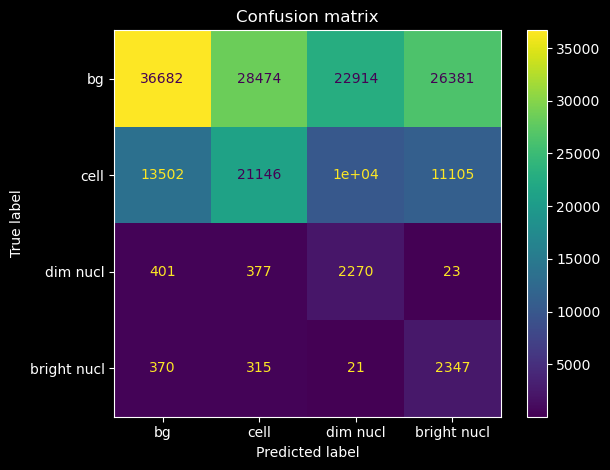

In [188]:
# patch level accum
embeds = embeddings.reshape(-1, embeddings.shape[-1])
preds = np.zeros((900*196,))
probas = np.zeros((900*196, 4))
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, patch_labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=patch_labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    probas[test_idcs] = clf_probas
    preds[test_idcs] = clf_preds
metrics = get_metrics(
    labels=patch_labels, probas=probas, preds=preds
)
print(metrics["f1_per_class"])
cm = confusion_matrix(patch_labels, preds)
plot_confusion_matrix(
    confusion_matrix=cm,
    display_labels=("bg", "cell", "dim nucl", "bright nucl"),
    # vmax=900*196*0.75,
    vmax=None,
    plt_style="dark_background",
    show=True,
)

In [102]:
# cls tokens
embeds = cls_embeddings
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[0.949750879382217, 0.9440653289868769, 0.979845669611128] [0.00477409253952298, 0.013420975971240397, 0.010985852484602467]


[0.949740034662045, 0.944, 0.979933110367893]


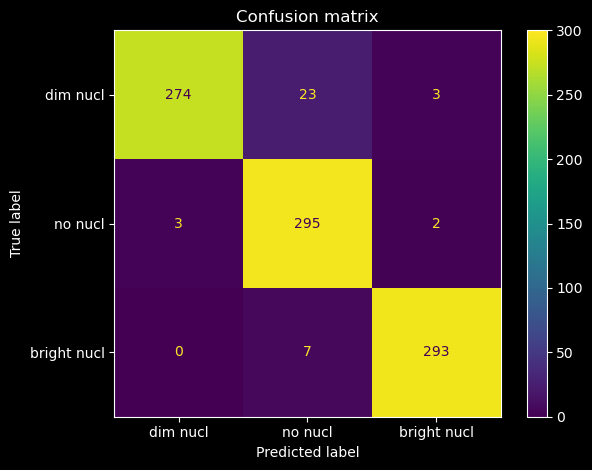

In [103]:
# cls tokens: accumulate over kfolds
embeds = cls_embeddings
preds = np.zeros((900,))
probas = np.zeros((900, 3))
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    probas[test_idcs] = clf_probas
    preds[test_idcs] = clf_preds
metrics = get_metrics(
    labels=labels, probas=probas, preds=preds
)
print(metrics["f1_per_class"])
cm = confusion_matrix(labels, preds)
plot_confusion_matrix(
    confusion_matrix=cm,
    display_labels=nucl_type_display_labels,
    plt_style="dark_background",
    show=True,
)

In [104]:
# mean of patch embed
embeds = embeddings.mean(axis=1)
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[0.9966499162479062, 0.9966832504145936, 1.0] [0.0023688669386484106, 0.0023452961233384555, 0.0]


In [106]:
# max of patch embed
embeds = embeddings.max(axis=1)
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[1.0, 1.0, 1.0] [0.0, 0.0, 0.0]


In [107]:
# log_spheres9, maester like, single channel, no norm pix loss

In [108]:
p = "/g/kreshuk/hellgoth/projects/ML4ExM_project/mae/spheres9/checkpoint-799.pth"
ckpt = torch.load(p, map_location="cpu")
model = my_models_mae.__dict__["mae_vit_base_patch16_maester"](
        norm_pix_loss=False,
        in_chans=1,
        loss_on_all_patches=True,
        pos_encode_w=1.0,
    )
model.load_state_dict(ckpt["model"])

<All keys matched successfully>

In [109]:
embeddings = np.zeros((len(dataset_val), 196, 192))
cls_embeddings = np.zeros((len(dataset_val), 192))
for i, sample in enumerate(tqdm(dataset_val)):  # sample is (image, label)
    latent, mask, ids_restore = model.forward_encoder(sample[0][None], 0.0)
    embeddings[i] = latent[0, 1:].detach().cpu().numpy()  # rmv cls token
    cls_embeddings[i] = latent[0, 0].detach().cpu().numpy()
embeddings.shape, cls_embeddings.shape

100%|██████████| 900/900 [00:19<00:00, 45.25it/s]


((900, 196, 192), (900, 192))

In [110]:
# cls tokens
embeds = cls_embeddings
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[0.951685477036289, 0.9310480502331097, 0.9655239532434771] [0.006761940104795828, 0.014349766320004564, 0.015161560558728759]


In [111]:
# mean of patch embed
embeds = embeddings.mean(axis=1)
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[0.98988181262497, 0.9820019962007791, 0.9915909513899464] [0.004165497804072238, 0.002276656625089527, 0.0023927948875236047]


In [112]:
# max of patch embed
embeds = embeddings.max(axis=1)
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[0.9983249581239532, 0.9983416252072969, 1.0] [0.0023688669386484106, 0.0023452961233384555, 0.0]


[0.9517241379310345, 0.9308176100628931, 0.9657534246575342]


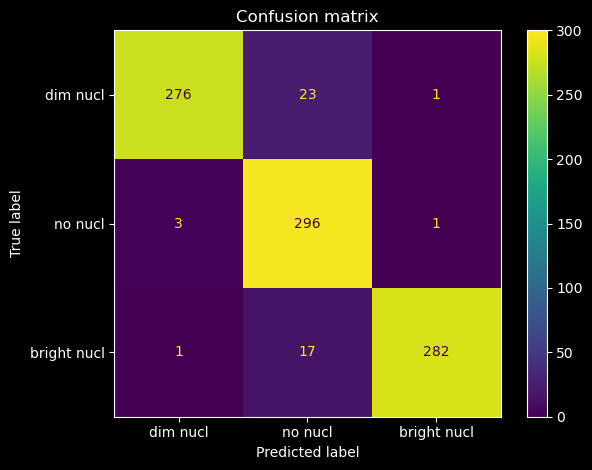

In [113]:
# cls tokens: accumulate over kfolds
embeds = cls_embeddings
preds = np.zeros((900,))
probas = np.zeros((900, 3))
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    probas[test_idcs] = clf_probas
    preds[test_idcs] = clf_preds
metrics = get_metrics(
    labels=labels, probas=probas, preds=preds
)
print(metrics["f1_per_class"])
cm = confusion_matrix(labels, preds)
plot_confusion_matrix(
    confusion_matrix=cm,
    display_labels=nucl_type_display_labels,
    plt_style="dark_background",
    show=True,
)

In [114]:
# log_spheres10, smaller model, single channel, no norm pix loss

In [115]:
p = "/g/kreshuk/hellgoth/projects/ML4ExM_project/mae/spheres10/checkpoint-799.pth"
ckpt = torch.load(p, map_location="cpu")
model = my_models_mae.__dict__["mae_vit_base_patch16_small"](
        norm_pix_loss=False,
        in_chans=1,
        loss_on_all_patches=True,
        pos_encode_w=1.0,
    )
model.load_state_dict(ckpt["model"])

<All keys matched successfully>

In [116]:
embeddings = np.zeros((len(dataset_val), 196, 128))
cls_embeddings = np.zeros((len(dataset_val), 128))
for i, sample in enumerate(tqdm(dataset_val)):  # sample is (image, label)
    latent, mask, ids_restore = model.forward_encoder(sample[0][None], 0.0)
    embeddings[i] = latent[0, 1:].detach().cpu().numpy()  # rmv cls token
    cls_embeddings[i] = latent[0, 0].detach().cpu().numpy()
embeddings.shape, cls_embeddings.shape

100%|██████████| 900/900 [00:18<00:00, 49.04it/s]


((900, 196, 128), (900, 128))

In [117]:
# cls tokens
embeds = cls_embeddings
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[0.9330138598955804, 0.9032203256293525, 0.9565982426455308] [0.016325425517219484, 0.0007283283827049738, 0.01547119504039674]


In [118]:
# mean of patch embed
embeds = embeddings.mean(axis=1)
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[0.9527465092666757, 0.9404712913269234, 0.9811590059747023] [0.011765770972593834, 0.005528029393472753, 0.013008705377228534]


In [119]:
# max of patch embed
embeds = embeddings.max(axis=1)
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[0.9898471951594708, 0.9885053474618752, 0.9983249581239532] [0.007251633485658368, 0.0060791410878207885, 0.0023688669386484106]


[0.9333333333333333, 0.9032258064516129, 0.9568221070811744]


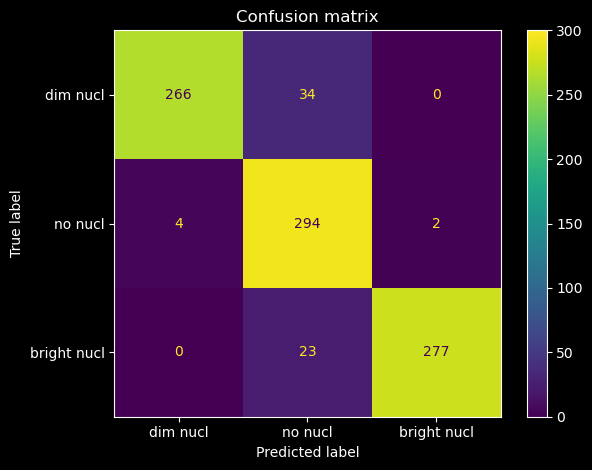

In [120]:
# cls tokens: accumulate over kfolds
embeds = cls_embeddings
preds = np.zeros((900,))
probas = np.zeros((900, 3))
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    probas[test_idcs] = clf_probas
    preds[test_idcs] = clf_preds
metrics = get_metrics(
    labels=labels, probas=probas, preds=preds
)
print(metrics["f1_per_class"])
cm = confusion_matrix(labels, preds)
plot_confusion_matrix(
    confusion_matrix=cm,
    display_labels=nucl_type_display_labels,
    plt_style="dark_background",
    show=True,
)

In [121]:
# log_spheres11, MAE, single channel, no norm pix loss, mask ratio 0.5

In [122]:
p = "/g/kreshuk/hellgoth/projects/ML4ExM_project/mae/spheres11/checkpoint-799.pth"
ckpt = torch.load(p, map_location="cpu")
model = my_models_mae.__dict__["mae_vit_base_patch16"](
        norm_pix_loss=False,
        in_chans=1,
        loss_on_all_patches=True,
        pos_encode_w=1.0,
    )
model.load_state_dict(ckpt["model"])

<All keys matched successfully>

In [123]:
embeddings = np.zeros((len(dataset_val), 196, 768))
cls_embeddings = np.zeros((len(dataset_val), 768))
for i, sample in enumerate(tqdm(dataset_val)):  # sample is (image, label)
    latent, mask, ids_restore = model.forward_encoder(sample[0][None], 0.0)
    embeddings[i] = latent[0, 1:].detach().cpu().numpy()  # rmv cls token
    cls_embeddings[i] = latent[0, 0].detach().cpu().numpy()
embeddings.shape, cls_embeddings.shape


100%|██████████| 900/900 [00:48<00:00, 18.70it/s]


((900, 196, 768), (900, 768))

In [124]:
# cls tokens
embeds = cls_embeddings
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[0.9932829128809028, 0.9917409651412902, 0.9983249581239532] [0.0023927948875236047, 0.0023220753696420607, 0.0023688669386484106]


In [125]:
# mean of patch embed
embeds = embeddings.mean(axis=1)
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[0.9966499162479062, 0.9950412951742935, 0.9983249581239532] [0.0023688669386484106, 0.004042078956547724, 0.0023688669386484106]


In [126]:
# max of patch embed
embeds = embeddings.max(axis=1)
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[1.0, 1.0, 1.0] [0.0, 0.0, 0.0]


[0.9932885906040269, 0.9917355371900827, 0.998330550918197]


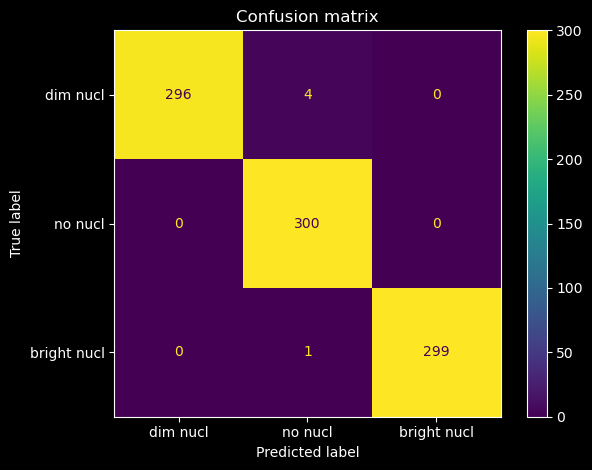

In [127]:
# cls tokens: accumulate over kfolds
embeds = cls_embeddings
preds = np.zeros((900,))
probas = np.zeros((900, 3))
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    probas[test_idcs] = clf_probas
    preds[test_idcs] = clf_preds
metrics = get_metrics(
    labels=labels, probas=probas, preds=preds
)
print(metrics["f1_per_class"])
cm = confusion_matrix(labels, preds)
plot_confusion_matrix(
    confusion_matrix=cm,
    display_labels=nucl_type_display_labels,
    plt_style="dark_background",
    show=True,
)

In [128]:
# log_spheres12, MAE, single channel, no norm pix loss, no standardization only normalization

In [129]:
transform_train = transforms.Compose(
    [
        transforms.ToTensor(),
        # transforms.Normalize(mean=0.17597473, std=0.23851053),
    ]
)

# CHANGED loader
def pil_loader_grey(path: str) -> Image:
    return Image.open(path)

dataset_val = datasets.ImageFolder(
    os.path.join("/scratch/hellgoth/data/spheres_small_2d_png/", "val"),
    loader=pil_loader_grey,
    transform=transform_train,
)
sample = dataset_val[0][0]
sample.shape, sample.min(), sample.max(), len(dataset_val)

(torch.Size([1, 224, 224]), tensor(0.), tensor(0.5490), 900)

In [130]:
p = "/g/kreshuk/hellgoth/projects/ML4ExM_project/mae/spheres12/checkpoint-799.pth"
ckpt = torch.load(p, map_location="cpu")
model = my_models_mae.__dict__["mae_vit_base_patch16"](
        norm_pix_loss=False,
        in_chans=1,
        loss_on_all_patches=True,
        pos_encode_w=1.0,
    )
model.load_state_dict(ckpt["model"])

<All keys matched successfully>

In [131]:
embeddings = np.zeros((len(dataset_val), 196, 768))
cls_embeddings = np.zeros((len(dataset_val), 768))
for i, sample in enumerate(tqdm(dataset_val)):  # sample is (image, label)
    latent, mask, ids_restore = model.forward_encoder(sample[0][None], 0.0)
    embeddings[i] = latent[0, 1:].detach().cpu().numpy()  # rmv cls token
    cls_embeddings[i] = latent[0, 0].detach().cpu().numpy()
embeddings.shape, cls_embeddings.shape

100%|██████████| 900/900 [00:47<00:00, 18.79it/s]


((900, 196, 768), (900, 768))

In [132]:
# cls tokens
embeds = cls_embeddings
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[0.9865817301229075, 0.9755300494181413, 0.9813519813519814] [0.002348917429562576, 0.004002831031241726, 0.006438644338076203]


In [133]:
# mean of patch embed
embeds = embeddings.mean(axis=1)
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[0.9932829128809028, 0.9933829203815904, 1.0] [0.0023927948875236047, 0.0023220753696420607, 0.0]


In [134]:
# max of patch embed
embeds = embeddings.max(axis=1)
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[0.9983249581239532, 0.9983416252072969, 1.0] [0.0023688669386484106, 0.0023452961233384555, 0.0]


[0.9865771812080537, 0.9755301794453507, 0.9813874788494078]


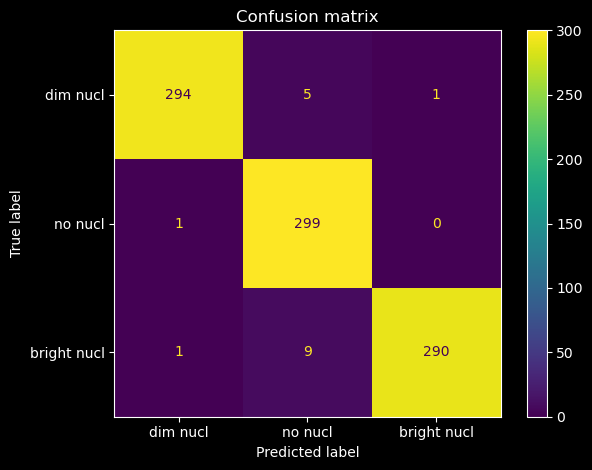

In [135]:
# cls tokens: accumulate over kfolds
embeds = cls_embeddings
preds = np.zeros((900,))
probas = np.zeros((900, 3))
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    probas[test_idcs] = clf_probas
    preds[test_idcs] = clf_preds
metrics = get_metrics(
    labels=labels, probas=probas, preds=preds
)
print(metrics["f1_per_class"])
cm = confusion_matrix(labels, preds)
plot_confusion_matrix(
    confusion_matrix=cm,
    display_labels=nucl_type_display_labels,
    plt_style="dark_background",
    show=True,
)

In [ ]:
# log_spheres12, shallow MAE, single channel, no norm pix loss

In [3]:
transform_train = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=0.17597473, std=0.23851053),
    ]
)

# CHANGED loader
def pil_loader_grey(path: str) -> Image:
    return Image.open(path)

dataset_val = datasets.ImageFolder(
    os.path.join("/scratch/hellgoth/data/spheres_small_2d_png/", "val"),
    loader=pil_loader_grey,
    transform=transform_train,
)
sample = dataset_val[0][0]
sample.shape, sample.min(), sample.max(), len(dataset_val)

(torch.Size([1, 224, 224]), tensor(-0.7378), tensor(1.5641), 900)

In [5]:
p = "/g/kreshuk/hellgoth/projects/ML4ExM_project/mae/spheres13/checkpoint-799.pth"
ckpt = torch.load(p, map_location="cpu")
model = my_models_mae.__dict__["mae_vit_base_patch16_shallow"](
        norm_pix_loss=False,
        in_chans=1,
        loss_on_all_patches=True,
        pos_encode_w=1.0,
    )
model.load_state_dict(ckpt["model"])

<All keys matched successfully>

In [6]:
embeddings = np.zeros((len(dataset_val), 196, 768))
cls_embeddings = np.zeros((len(dataset_val), 768))
for i, sample in enumerate(tqdm(dataset_val)):  # sample is (image, label)
    latent, mask, ids_restore = model.forward_encoder(sample[0][None], 0.0)
    embeddings[i] = latent[0, 1:].detach().cpu().numpy()  # rmv cls token
    cls_embeddings[i] = latent[0, 0].detach().cpu().numpy()
embeddings.shape, cls_embeddings.shape

100%|██████████| 900/900 [00:26<00:00, 33.49it/s]


((900, 196, 768), (900, 768))

In [9]:
# cls tokens
embeds = cls_embeddings
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[0.8746653868714338, 0.8810490418531348, 0.9658621772179249] [0.029184830883368085, 0.03411488997706762, 0.017026862742470953]


In [10]:
# mean of patch embed
embeds = embeddings.mean(axis=1)
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[0.9966499162479062, 0.9950412951742935, 0.9983249581239532] [0.0023688669386484106, 0.004042078956547724, 0.0023688669386484106]


In [11]:
# max of patch embed
embeds = embeddings.max(axis=1)
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    current_metrics = get_metrics(
        labels=labels[test_idcs], probas=clf_probas, preds=clf_preds
    )
    metrics.append(current_metrics)
summary_dict = summarize(metrics)
print(summary_dict["f1_per_class_mean"], summary_dict["f1_per_class_std"])

[1.0, 1.0, 1.0] [0.0, 0.0, 0.0]


[0.8747795414462081, 0.8806201550387597, 0.9659863945578231]


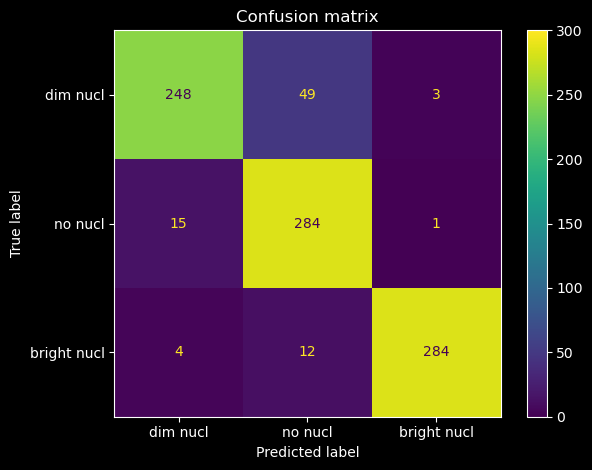

In [12]:
# cls tokens: accumulate over kfolds
embeds = cls_embeddings
preds = np.zeros((900,))
probas = np.zeros((900, 3))
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    probas[test_idcs] = clf_probas
    preds[test_idcs] = clf_preds
metrics = get_metrics(
    labels=labels, probas=probas, preds=preds
)
print(metrics["f1_per_class"])
cm = confusion_matrix(labels, preds)
plot_confusion_matrix(
    confusion_matrix=cm,
    display_labels=nucl_type_display_labels,
    plt_style="dark_background",
    show=True,
)

In [13]:
names = [
    "6-MAE",
    "7-MAE lossOnAll",
    "9-MAESTER",
    "10-MAE small",
    "11-MAE mask ration 0.5",
    "12-MAE norm only",
    "13-MAE shallow",
]
f1_cls = [
    [0.9611163954891294, 0.9525541056664374, 0.9666606048359938],
    [0.949750879382217, 0.9440653289868769, 0.979845669611128],
    [0.951685477036289, 0.9310480502331097, 0.9655239532434771],
    [0.9330138598955804, 0.9032203256293525, 0.9565982426455308],
    [0.9932829128809028, 0.9917409651412902, 0.9983249581239532],
    [0.9865817301229075, 0.9755300494181413, 0.9813519813519814],
    [0.8746653868714338, 0.8810490418531348, 0.9658621772179249],
]
f1_cls_std = [
    [0.0185756827138976, 0.023536185906572655, 0.020261864884985836],
    [0.00477409253952298, 0.013420975971240397, 0.010985852484602467],
    [0.006761940104795828, 0.014349766320004564, 0.015161560558728759],
    [0.016325425517219484, 0.0007283283827049738, 0.01547119504039674],
    [0.0023927948875236047, 0.0023220753696420607, 0.0023688669386484106],
    [0.002348917429562576, 0.004002831031241726, 0.006438644338076203],
    [0.029184830883368085, 0.03411488997706762, 0.017026862742470953],
]
f1_mean = [
    [0.9966499162479062, 0.9917735615926125, 0.9949579547569497],
    [0.9966499162479062, 0.9966832504145936, 1.0],
    [0.98988181262497, 0.9820019962007791, 0.9915909513899464],
    [0.9527465092666757, 0.9404712913269234, 0.9811590059747023],
    [0.9966499162479062, 0.9950412951742935, 0.9983249581239532],
    [0.9932829128809028, 0.9933829203815904, 1.0],
    [0.9966499162479062, 0.9950412951742935, 0.9983249581239532],
]
f1_mean_std = [
    [0.0023688669386484106, 0.00614832312571691, 0.004123737460945132],
    [0.0023688669386484106, 0.0023452961233384555, 0.0],
    [0.004165497804072238, 0.002276656625089527, 0.0023927948875236047],
    [0.011765770972593834, 0.005528029393472753, 0.013008705377228534],
    [0.0023688669386484106, 0.004042078956547724, 0.0023688669386484106],
    [0.0023927948875236047, 0.0023220753696420607, 0.0],
    [0.0023688669386484106, 0.004042078956547724, 0.0023688669386484106],
]
f1_max = [
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0],
    [0.9983249581239532, 0.9983416252072969, 1.0],
    [0.9898471951594708, 0.9885053474618752, 0.9983249581239532],
    [1.0, 1.0, 1.0],
    [0.9983249581239532, 0.9983416252072969, 1.0],
    [1.0, 1.0, 1.0],
]
f1_max_std = [
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [0.0023688669386484106, 0.0023452961233384555, 0.0],
    [0.007251633485658368, 0.0060791410878207885, 0.0023688669386484106],
    [0.0, 0.0, 0.0],
    [0.0023688669386484106, 0.0023452961233384555, 0.0],
    [0.0, 0.0, 0.0],
]
f1_cls_accum = [
    [0.961082910321489, 0.9525368248772504, 0.9665551839464883],
    [0.949740034662045, 0.944, 0.979933110367893],
    [0.9517241379310345, 0.9308176100628931, 0.9657534246575342],
    [0.9333333333333333, 0.9032258064516129, 0.9568221070811744],
    [0.9932885906040269, 0.9917355371900827, 0.998330550918197],
    [0.9865771812080537, 0.9755301794453507, 0.9813874788494078],
    [0.8747795414462081, 0.8806201550387597, 0.9659863945578231],
]

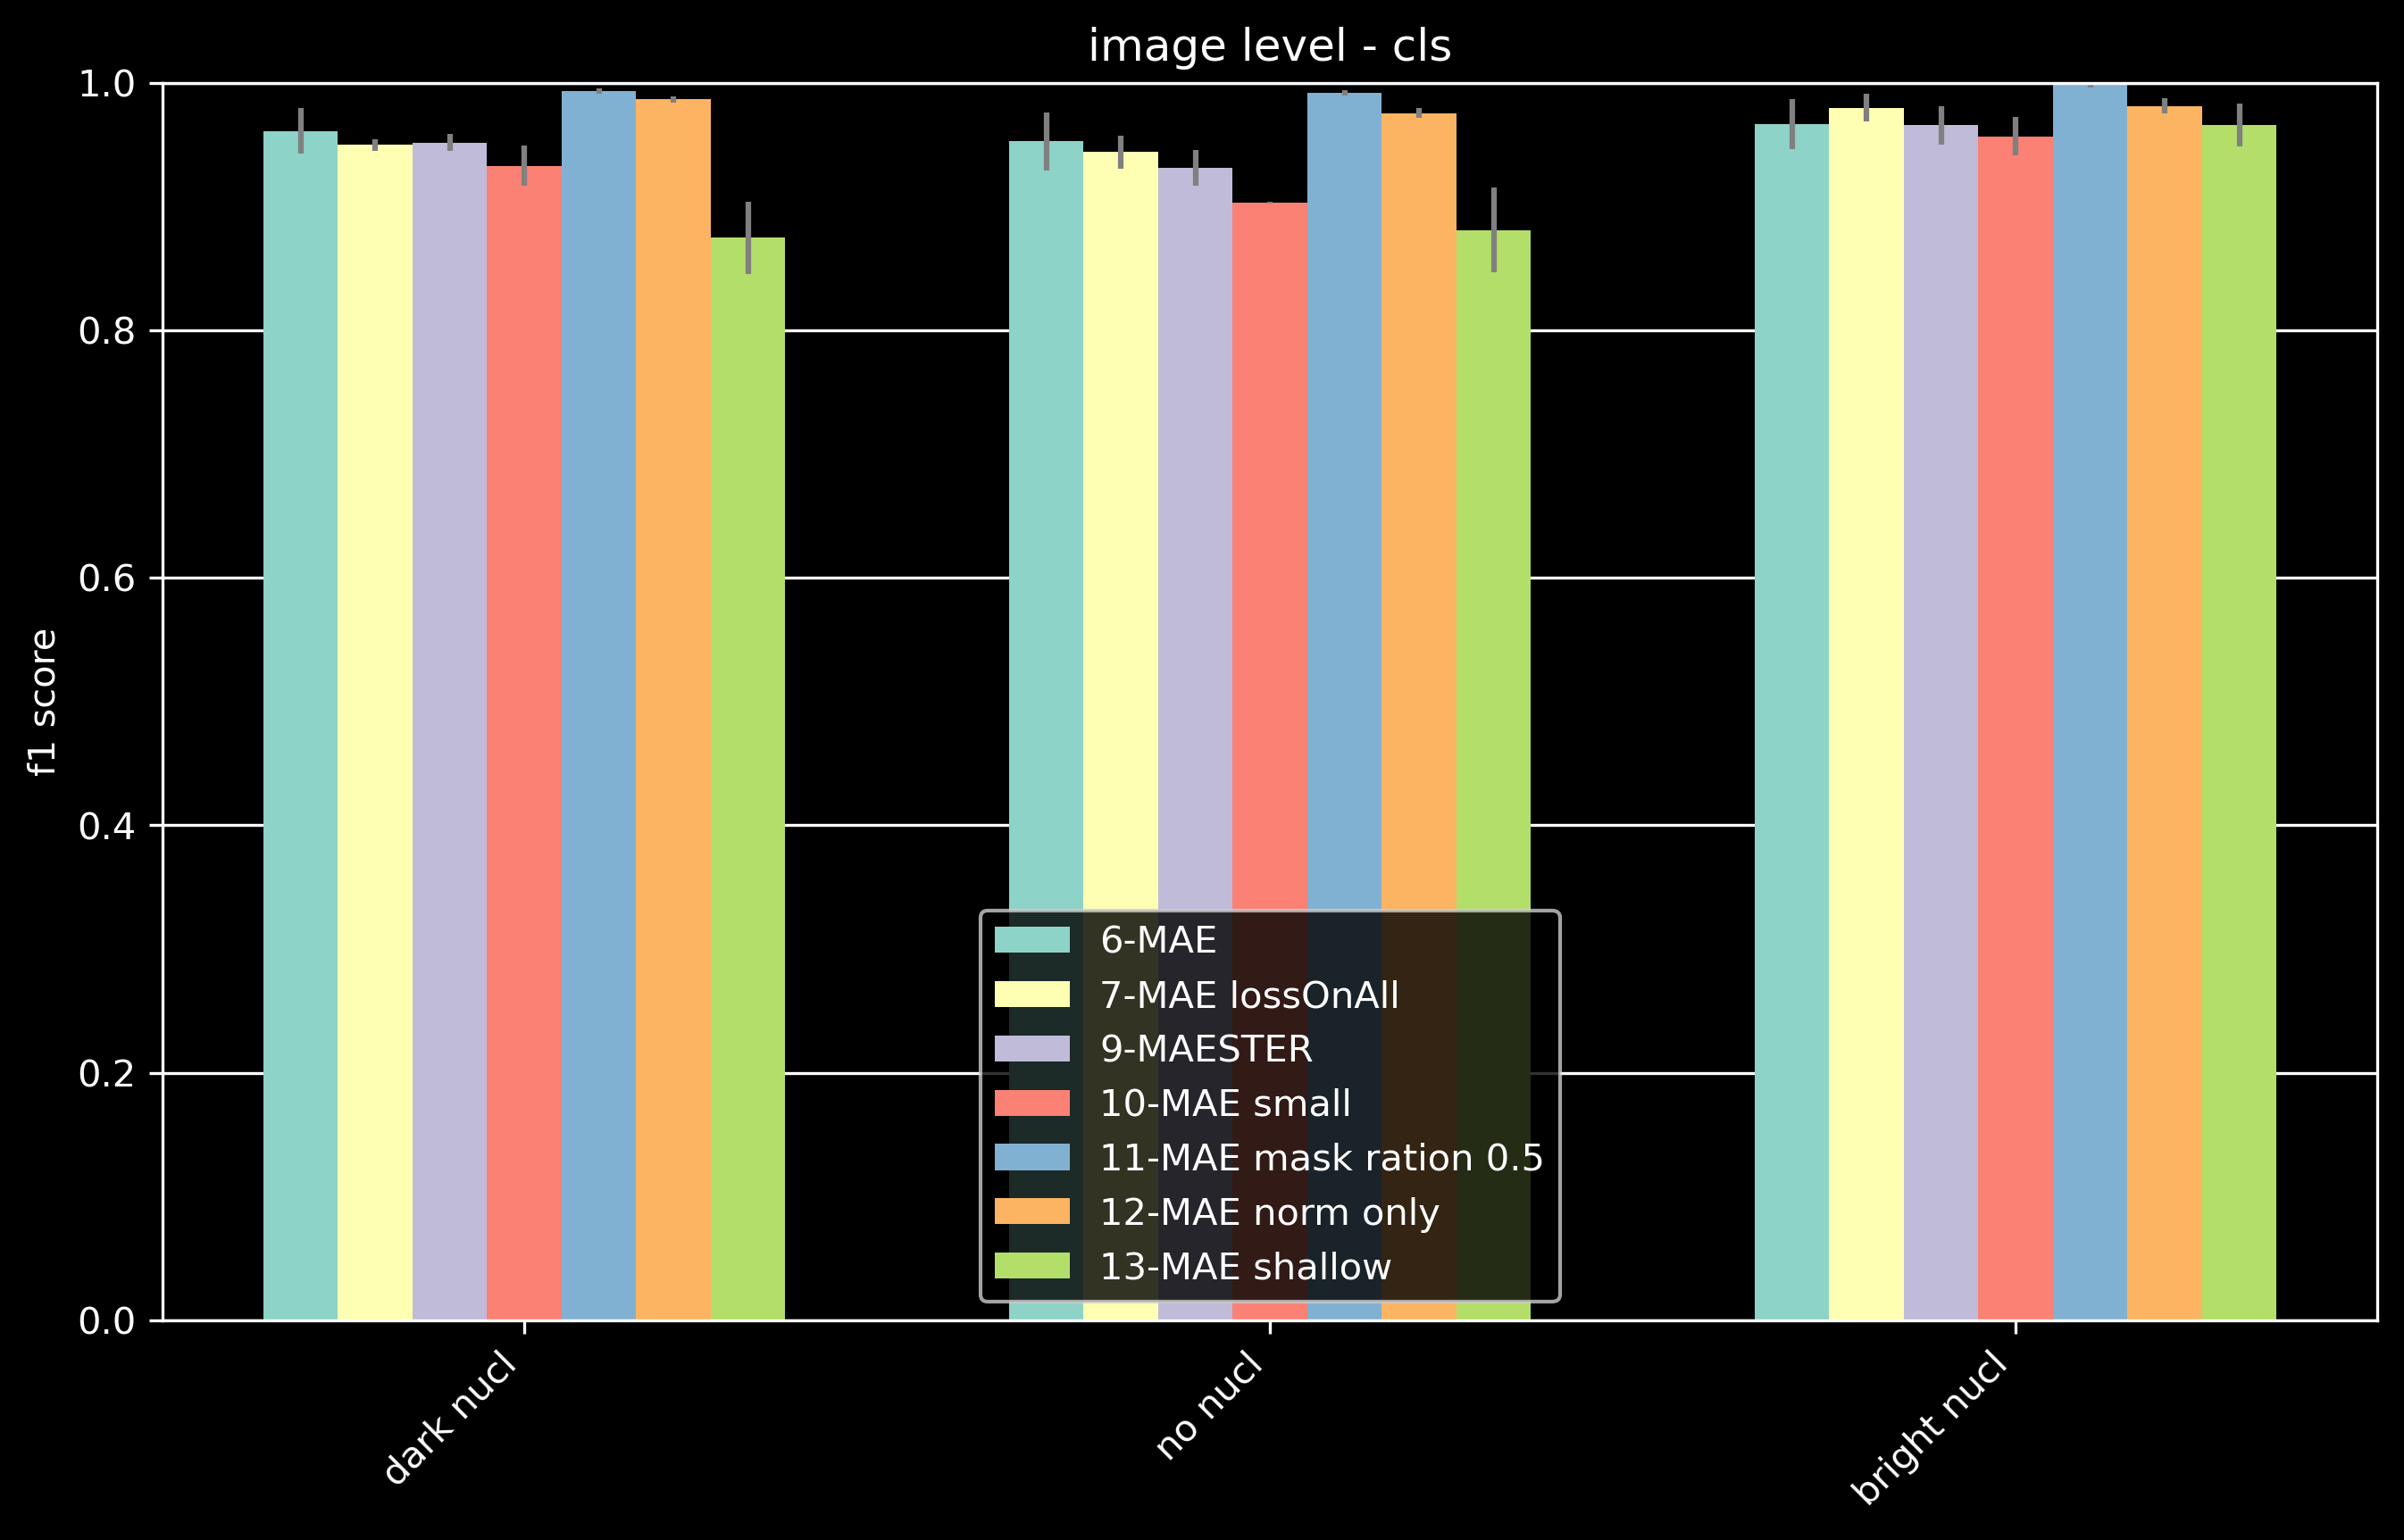

In [14]:
# image level f1
plt.style.use("dark_background")
plt.figure(dpi=300, figsize=(16 / 1.5, 9 / 1.5))
x_labels = ["dark nucl", "no nucl", "bright nucl"]
x = np.arange(len(x_labels))
width = 0.1

for i in range(len(names)):
    plt.bar(
        x + i * width,
        f1_cls[i],
        width,
        yerr=f1_cls_std[i],
        label=names[i],
        error_kw=dict(ecolor="gray"),
    )


plt.ylabel("f1 score")
plt.xticks(x + 3 * width, x_labels, rotation=45, ha="right")
plt.grid(axis="y")
plt.gca().set_axisbelow(True)
plt.ylim(0, 1)
plt.title("image level - cls")
plt.legend(loc="lower center")
plt.show()

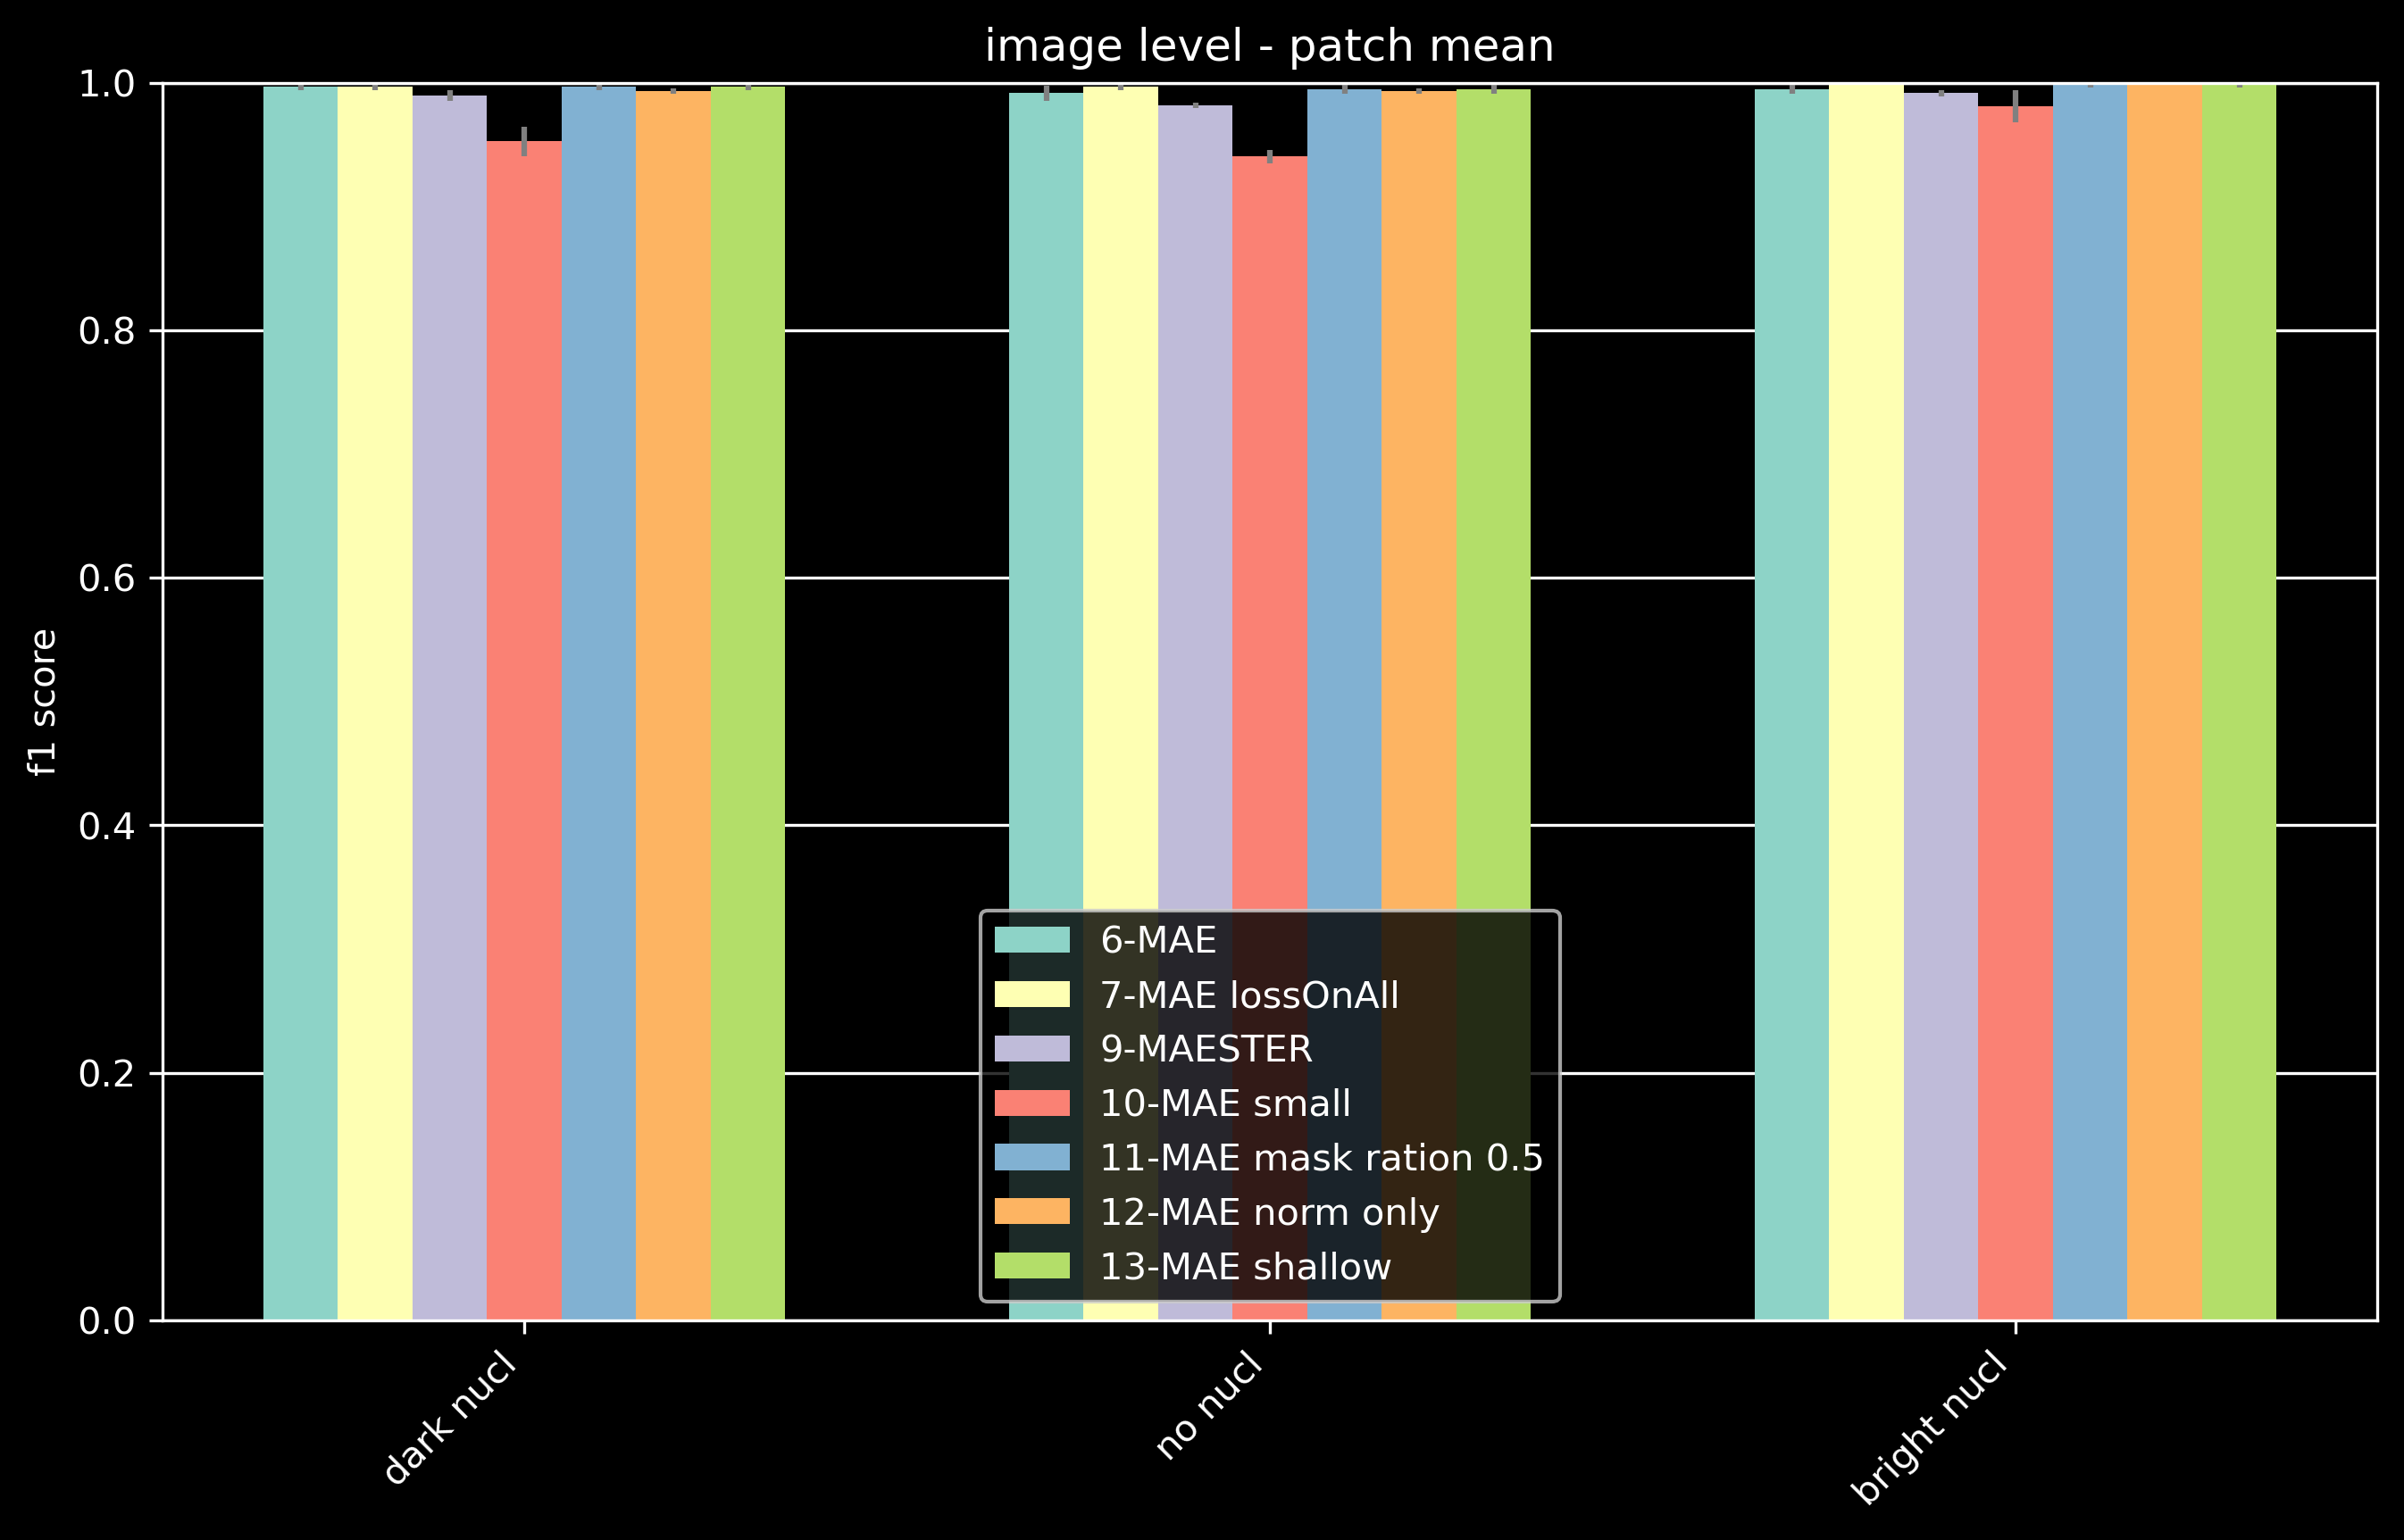

In [15]:
# image level f1
plt.style.use("dark_background")
plt.figure(dpi=300, figsize=(16 / 1.5, 9 / 1.5))
x_labels = ["dark nucl", "no nucl", "bright nucl"]
x = np.arange(len(x_labels))
width = 0.1

for i in range(len(names)):
    plt.bar(
        x + i * width,
        f1_mean[i],
        width,
        yerr=f1_mean_std[i],
        label=names[i],
        error_kw=dict(ecolor="gray"),
    )


plt.ylabel("f1 score")
plt.xticks(x + 3 * width, x_labels, rotation=45, ha="right")
plt.grid(axis="y")
plt.gca().set_axisbelow(True)
plt.ylim(0, 1)
plt.title("image level - patch mean")
plt.legend(loc="lower center")
plt.show()

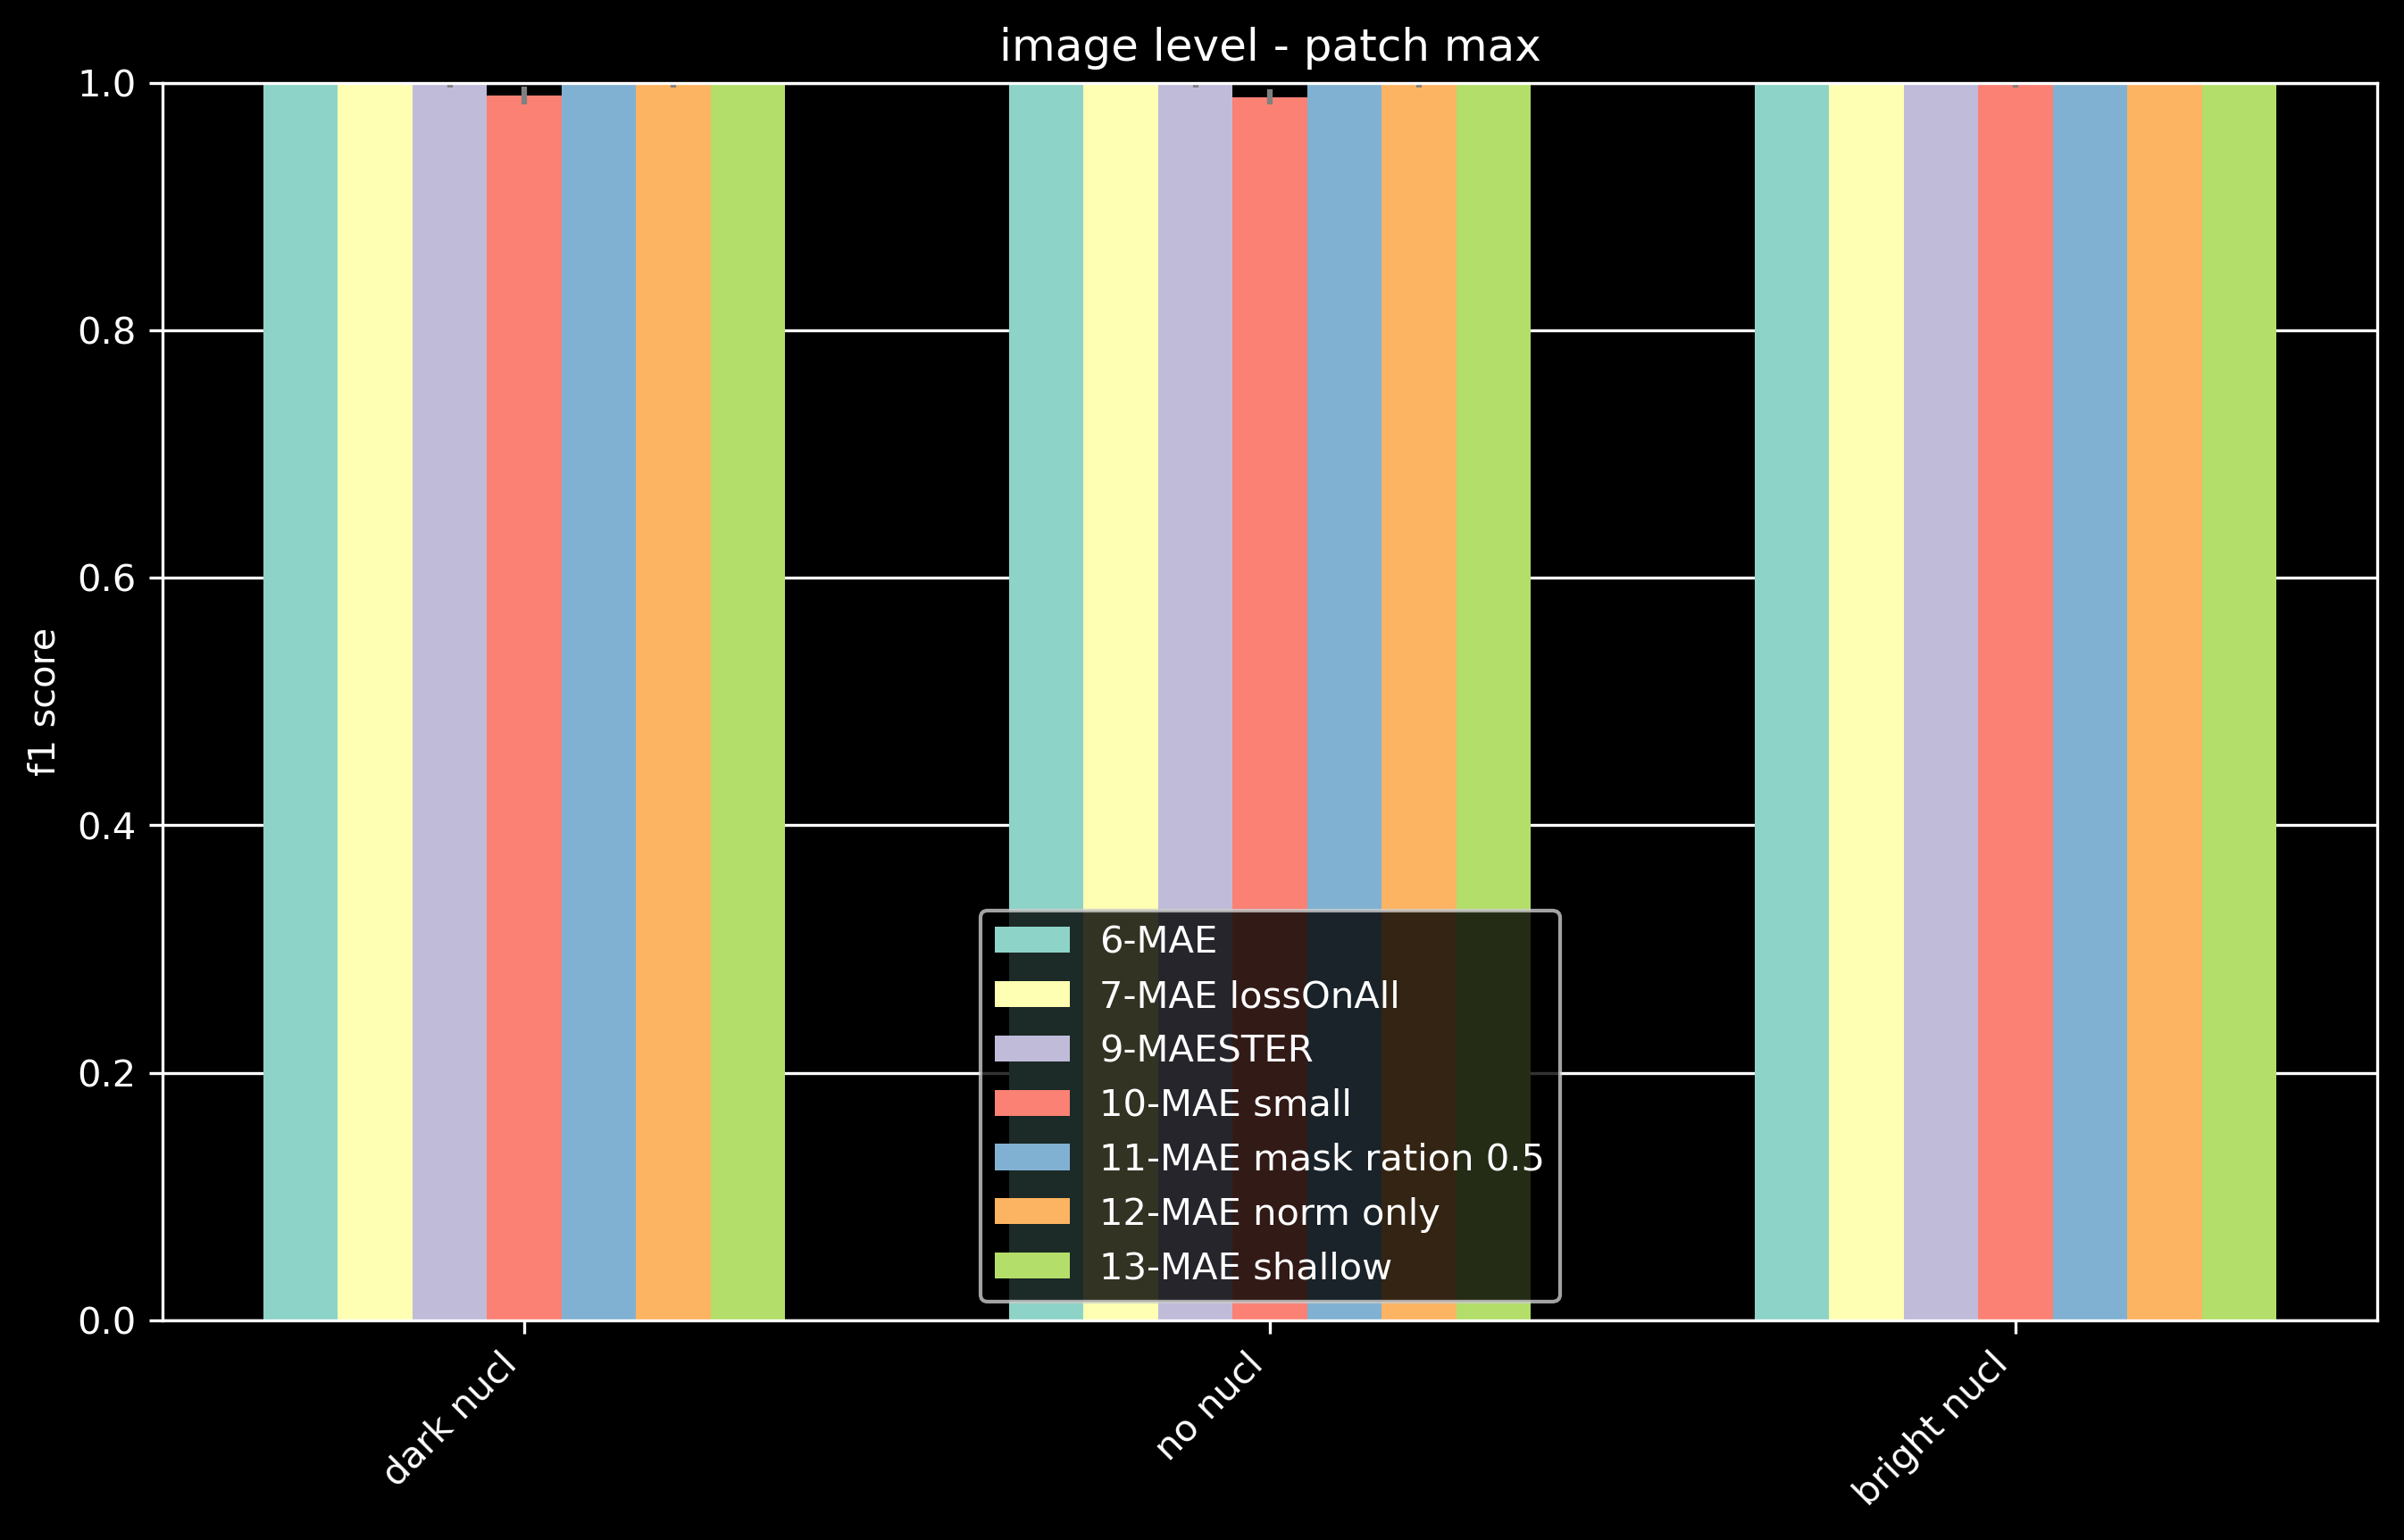

In [16]:
# image level f1
plt.style.use("dark_background")
plt.figure(dpi=300, figsize=(16 / 1.5, 9 / 1.5))
x_labels = ["dark nucl", "no nucl", "bright nucl"]
x = np.arange(len(x_labels))
width = 0.1

for i in range(len(names)):
    plt.bar(
        x + i * width,
        f1_max[i],
        width,
        yerr=f1_max_std[i],
        label=names[i],
        error_kw=dict(ecolor="gray"),
    )


plt.ylabel("f1 score")
plt.xticks(x + 3 * width, x_labels, rotation=45, ha="right")
plt.grid(axis="y")
plt.gca().set_axisbelow(True)
plt.ylim(0, 1)
plt.title("image level - patch max")
plt.legend(loc="lower center")
plt.show()

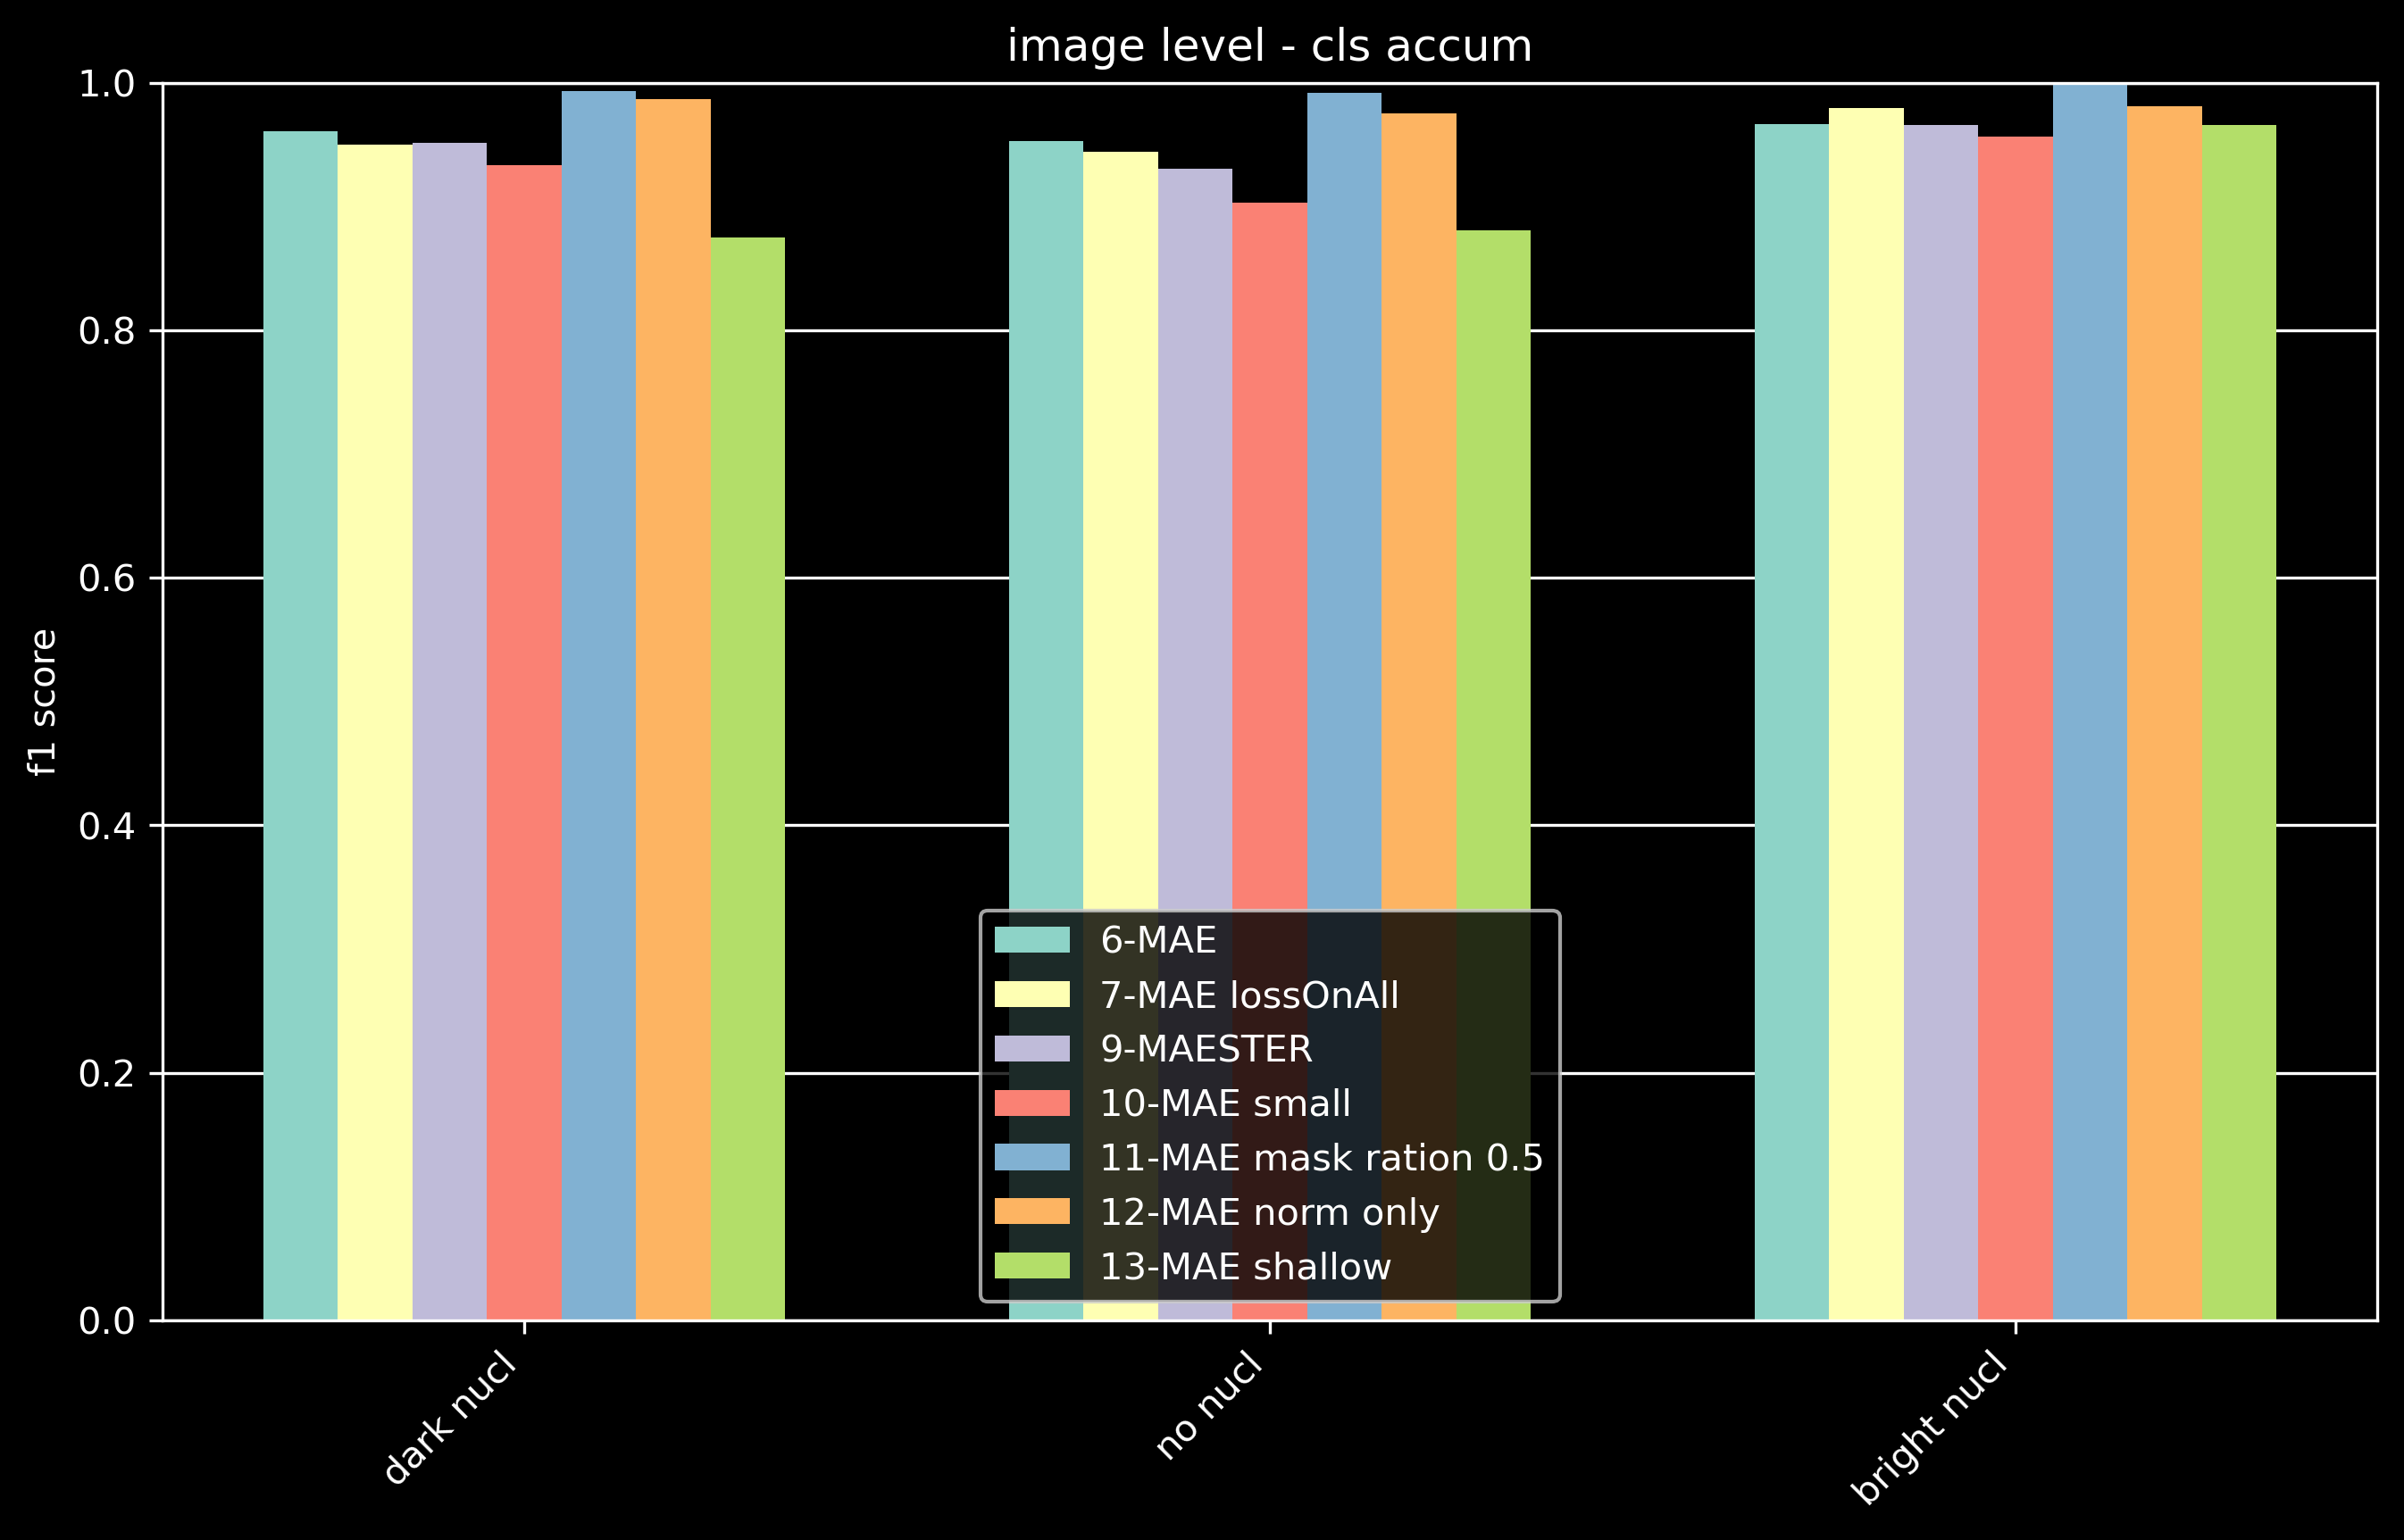

In [17]:
# image level f1
plt.style.use("dark_background")
plt.figure(dpi=300, figsize=(16 / 1.5, 9 / 1.5))
x_labels = ["dark nucl", "no nucl", "bright nucl"]
x = np.arange(len(x_labels))
width = 0.1

for i in range(len(names)):
    plt.bar(
        x + i * width,
        f1_cls_accum[i],
        width,
        label=names[i],
        error_kw=dict(ecolor="gray"),
    )


plt.ylabel("f1 score")
plt.xticks(x + 3 * width, x_labels, rotation=45, ha="right")
plt.grid(axis="y")
plt.gca().set_axisbelow(True)
plt.ylim(0, 1)
plt.title("image level - cls accum")
plt.legend(loc="lower center")
plt.show()